# DoubleIntegrator — Stage 4 — Safe Online Adaptation (Barrier vs. PSF)

Compare barrier-safe adaptation with the configured baselines.


## 1. Set up the system and load the stage config

Load dependencies and configuration.


In [1]:
"""Boilerplate: make the in-repo `sdpc` package importable and resolve this system."""
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_p = Path.cwd()
while not (_p / "src" / "sdpc").exists():
    _p = _p.parent
sys.path.insert(0, str(_p / "src"))

import torch
from sdpc.config import load_config
from sdpc.registry import make_system

SYSTEM = "double_integrator"
device = torch.device("cpu")
system = make_system(SYSTEM, device=device)
CONFIGS = Path.cwd().parent / "configs"
RESULTS = Path.cwd().parent / "results"

print(f"System        : {SYSTEM}")
print(f"State dim nx  : {system.nx}")
print(f"Control dim nu: {system.nu}")
print(f"Sample time ts: {system.ts}")
print(f"Input bounds  : [{system.umin}, {system.umax}]")
print(f"State bounds  : [{system.xmin}, {system.xmax}]")
print(f"Discrete model: {system.is_discrete}")


System        : double_integrator
State dim nx  : 2
Control dim nu: 2
Sample time ts: 1.0
Input bounds  : [-1.0, 1.0]
State bounds  : [-5.0, 5.0]
Discrete model: True


In [2]:
cfg = load_config(CONFIGS / 'safe.yaml')
print('Resolved safe-adaptation config:')
for k, v in cfg.items():
    if not k.startswith('_'):
        print(f'  {k}: {v}')

Resolved safe-adaptation config:
  seed: 3
  nsteps: 100
  ellipse: {'p': 5, 'b': 3, 'c': -0.5, 'd': 0.0, 'theta': -0.6}
  init_center: [3, -3]
  init_side: 1.5
  ref_center: [-2.5, 2.0]
  ref_side: 0.001
  action_scale: 1.0
  perturbation: {'A': [[1.0, 0.05], [0.05, 1.0]], 'B': [[1.0, 0.0], [0.0, 1.0]]}
  weights: {'Q_con_obs': 20.0, 'Q_con_x': 10.0, 'Q_con_du': 1.0}
  bands: {'obstacle': 4.0, 'box': 0.1, 'du': 0.0001}
  du_max: 0.25
  metrics: {'reach_tolerance': 0.05, 'reach_hold_steps': 5}
  safe: {'horizon': 15, 'gamma_ref': 0.05, 'gamma_safe': 0.005, 'clip_update': 0.5, 'safety_grad_max_norm': 1.0, 'max_safety_iters': 50, 'barrier_kind': 'relaxed_log', 'barrier_eps': 1e-06, 'action_scale': 1.0, 'ref_backend': 'symbolic', 'safety_backend': 'symbolic', 'action_gradient_mode': 'leaky_straight_through', 'action_gradient_band': 0.5, 'action_gradient_leak': 0.05, 'integration_method': 'euler', 'adaptive_gamma': True, 'gamma_ref_min': 0.02, 'gamma_ref_max': 0.6, 'gamma_err_scale': 1.5}


## 2. Load the trained policy and build the safety specification

Restore the required checkpoints.


In [3]:
from sdpc.sindy import load_model

from sdpc.io import find_policy_checkpoint
policy_path = find_policy_checkpoint(RESULTS, cfg)
policy = load_model(policy_path, device=device)

plant = system.perturbed_plant(cfg)
derivative_model = system.perturbed_sindy_model(cfg)
spec = system.safety_specs(cfg)

print('Safety constraints:', [c.name for c in spec.state_constraints])
print('Control-rate limit :', spec.control_rate.du_max if spec.control_rate else None)

Safety constraints: ['obstacle', 'x0_min', 'x0_max', 'x1_min', 'x1_max']
Control-rate limit : 0.25


In [4]:
policy.pretty_print()

u0 = -3.4409e-02·x0 + +1.1809e-02·x1 + +3.3027e-02·r0 + -2.9861e-02·r1 + -6.1995e-03·r0*r1 + -2.1325e-02·sin(1·r0)
u1 = -2.3651e-02·x1 + -9.5745e-03·x0*r1 + +1.2364e-02·sin(1·x1) + -2.6566e-02·sin(1·r0)


## 3. Sample a deployment scenario

By default this draws a single random initial state and a **constant** reference target held for the whole horizon (`cfg['ref_target']`).

In [5]:
from sdpc.eval import sample_scenario

data = sample_scenario(system, cfg, cfg.get('seed', 0), device)
print('Initial state:', data['xn'][0, 0].tolist())
print('Reference target:', data['r'][0, -1].tolist())
print('Horizon length (steps):', data['r'].shape[1] - 1)

Initial state: [2.3784737586975098, -2.6161017417907715]
Reference target: [-2.5002822875976562, 2.000149965286255]
Horizon length (steps): 100


## 3b. Longer horizon with a changing reference (optional)

Configure the reference signal.


In [6]:
from sdpc.data.reference import make_piecewise_reference, make_signal_reference

n_long = 400  # longer than the default cfg['nsteps']

# Option 1: hand-written piecewise schedule
lo = system.xmin + 0.2 * (system.xmax - system.xmin)
mid = system.xmin + 0.5 * (system.xmax - system.xmin)
hi = system.xmin + 0.8 * (system.xmax - system.xmin)
r_manual = make_piecewise_reference(
    system.nx,
    [([lo] * system.nx, 100), ([hi] * system.nx, 150), ([mid] * system.nx, 150)],
    device=device,
)

# Option 2: a neuromancer signal generator (piecewise-constant random levels)
r_signal = make_signal_reference(
    system.nx, n_long, kind='step', seed=cfg.get('seed', 0), device=device,
    min=lo, max=hi, randsteps=6,
)

print('manual reference shape :', tuple(r_manual.shape))
print('signal reference shape :', tuple(r_signal.shape))

# Swap in one of these for the rest of the notebook, e.g.:
# data = {'xn': data['xn'], 'r': r_manual}

manual reference shape : (1, 400, 2)
signal reference shape : (1, 401, 2)


## 4. Baseline: the frozen policy on the perturbed (noisy) plant

Create the deployment model.


In [7]:
import copy
from sdpc.eval import rollout_closed_loop

res_frozen = rollout_closed_loop(
    copy.deepcopy(policy), plant, data,
    umin=system.umin, umax=system.umax,
    action_scale=cfg.get('action_scale', 1.0),
)
frozen_margins = spec.min_margins(res_frozen['x_traj'])
final_err = (data['r'][0, -1] - res_frozen['x_traj'][0, -1]).norm().item()
print(f'Frozen policy — final tracking error: {final_err:.4f}')
print('Frozen policy — worst-case margins over the whole rollout:')
for name, m in frozen_margins.items():
    flag = ' <-- VIOLATED' if m < 0 else ''
    print(f'  {name}: {m:.4f}{flag}')

Frozen policy — final tracking error: 14.8209
Frozen policy — worst-case margins over the whole rollout:
  obstacle: -2.9294 <-- VIOLATED
  x0_min: -7.6050 <-- VIOLATED
  x0_max: 2.6215
  x1_min: -3.8422 <-- VIOLATED
  x1_max: 6.6103


## 5. Unconstrained adaptation (no safety) on this scenario

Run Stage 3's law here too, so we have a direct comparison against the same perturbed plant and scenario.

In [8]:
from sdpc.adaptation import (
    UnconstrainedAdaptationConfig, prepare_unconstrained_adaptation,
    run_unconstrained_adaptation,
)

# One-time backend preparation. The Jacobian must bind to the same mutable
# policy instance that will be adapted in the online cell below.
_unc_fields = set(UnconstrainedAdaptationConfig.__dataclass_fields__)
_raw = cfg.get('unconstrained', cfg.get('safe', {}))
ucfg = UnconstrainedAdaptationConfig(**{k: v for k, v in _raw.items() if k in _unc_fields})
unsafe_policy = copy.deepcopy(policy)
unsafe_prepared = prepare_unconstrained_adaptation(
    unsafe_policy, ucfg, umin=system.umin, umax=system.umax,
    derivative_model=derivative_model, system=system,
)
print('Reference backend:', ucfg.ref_backend)
print(f'One-time reference setup: {unsafe_prepared.setup_time_s:.6f} s')
print('Symbolic reference Jacobian:', unsafe_prepared.reference_jacobian is not None)

Reference backend: symbolic
One-time reference setup: 0.000191 s
Symbolic reference Jacobian: True


In [9]:
res_unsafe = run_unconstrained_adaptation(
    unsafe_policy, plant, data, ucfg,
    umin=system.umin, umax=system.umax,
    prepared=unsafe_prepared,
)
unsafe_margins = spec.min_margins(res_unsafe['x_traj'])
print('Unconstrained adaptation — worst-case margins over the whole rollout:')
for name, m in unsafe_margins.items():
    flag = ' <-- VIOLATED' if m < 0 else ''
    print(f'  {name}: {m:.4f}{flag}')

Unconstrained adaptation — worst-case margins over the whole rollout:
  obstacle: -2.9093 <-- VIOLATED
  x0_min: 0.8650
  x0_max: 2.6215
  x1_min: 2.3839
  x1_max: 2.4786


## 6. Run barrier-augmented safe adaptation (Algorithm 2)

Run predictive safety adaptation.


In [10]:
from sdpc.adaptation import SafeAdaptationConfig, prepare_safe_adaptation

# One-time preparation selected by the config. Autograd backends leave their
# corresponding Jacobian as None; symbolic backends build it here.
scfg = SafeAdaptationConfig(**cfg.get('safe', {}))
safe_policy = copy.deepcopy(policy)
safe_prepared = prepare_safe_adaptation(
    safe_policy, plant, scfg,
    umin=system.umin, umax=system.umax,
    pred_plant=plant, derivative_model=derivative_model, system=system,
)
print('Safe-adaptation settings:', scfg)
print('Prepared reference backend:', scfg.ref_backend,
      safe_prepared.reference_jacobian is not None)
print('Prepared safety backend  :', scfg.safety_backend,
      safe_prepared.safety_jacobian is not None)
print('One-time preparation')
print(f'  total                    {safe_prepared.setup_total_s:.6f} s')
print(f'  prediction callable      {safe_prepared.prediction_setup_s:.6f} s')
print(f'  reference Jacobian       {safe_prepared.reference_jacobian_setup_s:.6f} s')
print(f'  safety Jacobian          {safe_prepared.safety_jacobian_setup_s:.6f} s')

Safe-adaptation settings: SafeAdaptationConfig(horizon=15, gamma_ref=0.05, gamma_safe=0.005, clip_update=0.5, safety_grad_max_norm=1.0, safety_gain=1.0, max_safety_iters=50, barrier_kind='relaxed_log', barrier_eps=1e-06, safety_loss_tol=1e-10, action_scale=1.0, integration_method='euler', ref_backend='symbolic', safety_backend='symbolic', action_gradient_mode='leaky_straight_through', action_gradient_band=0.5, action_gradient_leak=0.05, adaptive_gamma=True, gamma_ref_min=0.02, gamma_ref_max=0.6, gamma_err_scale=1.5, verbose=False)
Prepared reference backend: symbolic True
Prepared safety backend  : symbolic True
One-time preparation
  total                    0.000118 s
  prediction callable      0.000000 s
  reference Jacobian       0.000104 s
  safety Jacobian          0.000012 s


In [11]:
from sdpc.adaptation import run_safe_adaptation
import time

adaptation_cell_t0 = time.perf_counter()
res = run_safe_adaptation(
    safe_policy, plant, data, spec, scfg,
    umin=system.umin, umax=system.umax,
    prepared=safe_prepared,
)
adaptation_cell_wall = time.perf_counter() - adaptation_cell_t0

at = res['timing']
n_online = len(res['logs'])
print('\nOnline safe-adaptation timing breakdown')
print(f"  {'cell wall total':32s} {adaptation_cell_wall:9.4f} s")
print(f"  {'runner total':32s} {at['total_s']:9.4f} s")
for label, key in [
    ('online total', 'online_total_s'),
    ('  reference updates', 'reference_update_total_s'),
    ('    reference derivatives', 'reference_gradient_total_s'),
    ('    coefficient updates', 'reference_apply_total_s'),
    ('    reference overhead', 'reference_overhead_s'),
    ('  safety rollout total', 'safety_rollout_total_s'),
    ('    predictive dynamics', 'safety_prediction_total_s'),
    ('    safety-loss evaluation', 'safety_loss_total_s'),
    ('    rollout overhead', 'safety_rollout_overhead_s'),
    ('  safety gradient total', 'safety_gradient_total_s'),
    ('    safety derivatives', 'safety_derivative_total_s'),
    ('    coefficient updates', 'safety_update_total_s'),
    ('    gradient overhead', 'safety_gradient_overhead_s'),
    ('  applied policy + plant steps', 'plant_step_total_s'),
    ('  safety diagnostics', 'diagnostics_total_s'),
    ('  online loop overhead', 'online_overhead_s'),
]:
    value = at[key]
    rate = f'  ({1e3 * value / n_online:.4f} ms/step)'
    print(f'  {label:32s} {value:9.4f} s{rate}')


Online safe-adaptation timing breakdown
  cell wall total                     0.3989 s
  runner total                        0.3988 s
  online total                        0.3976 s  (3.9759 ms/step)
    reference updates                 0.0496 s  (0.4963 ms/step)
      reference derivatives           0.0444 s  (0.4435 ms/step)
      coefficient updates             0.0052 s  (0.0525 ms/step)
      reference overhead              0.0000 s  (0.0003 ms/step)
    safety rollout total              0.2503 s  (2.5026 ms/step)
      predictive dynamics             0.2095 s  (2.0950 ms/step)
      safety-loss evaluation          0.0383 s  (0.3830 ms/step)
      rollout overhead                0.0025 s  (0.0246 ms/step)
    safety gradient total             0.0807 s  (0.8072 ms/step)
      safety derivatives              0.0772 s  (0.7720 ms/step)
      coefficient updates             0.0035 s  (0.0350 ms/step)
      gradient overhead               0.0000 s  (0.0002 ms/step)
    applied policy +

## 7. Predictive Safety Filter baseline (Algorithm 3)

Run the safety-filter baseline.


In [12]:
from sdpc.adaptation import PSFConfig, run_psf_adaptation, casadi_available
import time

assert casadi_available(), "PSF comparison requires CasADi in the active environment"
psf_cell_t0 = time.perf_counter()
pcfg = PSFConfig(**cfg.get('psf', {}))
print('PSF settings:', pcfg)

res_psf = run_psf_adaptation(
    copy.deepcopy(policy), plant, data, spec, pcfg,
    system=system, system_cfg=cfg,
    umin=system.umin, umax=system.umax,
)
psf_cell_wall = time.perf_counter() - psf_cell_t0

pt = res_psf['timing']
n_online = len(res_psf['logs'])
print('\nPSF timing breakdown')
print(f"  {'cell wall total':32s} {psf_cell_wall:9.4f} s")
print(f"  {'runner total':32s} {pt['total_s']:9.4f} s")
for label, key in [
    ('setup total', 'setup_total_s'),
    ('  CasADi solver creation', 'solver_setup_s'),
    ('  other setup', 'setup_overhead_s'),
    ('online total', 'online_total_s'),
    ('  reference updates', 'reference_update_total_s'),
    ('    reference derivatives', 'reference_gradient_total_s'),
    ('    coefficient updates', 'reference_apply_total_s'),
    ('    reference overhead', 'reference_overhead_s'),
    ('  full filter call', 'filter_wrapper_total_s'),
    ('    parameter/guess preparation', 'filter_prepare_total_s'),
    ('    initial trajectory guesses', 'filter_initialization_total_s'),
    ('    IPOPT solver', 'filter_solver_total_s'),
    ('    solution extraction', 'filter_extraction_total_s'),
    ('    unattributed call overhead', 'filter_unattributed_total_s'),
    ('    outer timing overhead', 'filter_outer_overhead_s'),
    ('  applied plant steps', 'plant_step_total_s'),
    ('  safety diagnostics', 'diagnostics_total_s'),
    ('  online loop overhead', 'online_overhead_s'),
]:
    value = pt[key]
    rate = '' if 'setup' in key else f'  ({1e3 * value / n_online:.4f} ms/step)'
    print(f'  {label:32s} {value:9.4f} s{rate}')
print(f"Realized violations     : {sum(row['realized_violation'] for row in res_psf['logs'])}")


PSF settings: PSFConfig(horizon=15, gamma_ref=0.05, clip_update=0.5, action_scale=1.0, action_gradient_mode='leaky_straight_through', action_gradient_band=0.5, action_gradient_leak=0.05, integration_method='euler', adaptive_gamma=True, gamma_ref_min=0.05, gamma_ref_max=0.6, gamma_err_scale=1.5, default_buffer=0.0, buffers={'obstacle': 4.0, 'box': 0.1, 'du': 0.001}, tail_weight=0.0, smooth_weight=0.0, max_iter=1000, tol=0.005, verbose=False)

PSF timing breakdown
  cell wall total                     0.7271 s
  runner total                        0.7248 s
  setup total                         0.0181 s
    CasADi solver creation            0.0175 s
    other setup                       0.0007 s
  online total                        0.7067 s  (7.0667 ms/step)
    reference updates                 0.0701 s  (0.7011 ms/step)
      reference derivatives           0.0541 s  (0.5413 ms/step)
      coefficient updates             0.0159 s  (0.1594 ms/step)
      reference overhead              

## 8. Per-step safety log

Inspect safety diagnostics over time.


In [13]:
print(f"{'t':>4} {'pred_safe':>10} {'iters':>6} {'barrier_loss':>13} "
      f"{'min_margin':>11} {'realized_viol':>13}")
for l in res['logs'][::max(1, len(res['logs']) // 20)]:
    print(f"{l['t']:>4} {str(l['predicted_safe']):>10} {l['safety_iters']:>6} "
          f"{l['barrier_loss']:>13.3e} {l['min_pred_margin']:>11.4f} "
          f"{str(l['realized_violation']):>13}")

n_safe = sum(l['predicted_safe'] for l in res['logs'])
n_real_viol = sum(l['realized_violation'] for l in res['logs'])
total_iters = sum(l['safety_iters'] for l in res['logs'])
print(f"\nSteps predicted-safe at commit : {n_safe} / {len(res['logs'])}")
print(f"Steps with a realized violation: {n_real_viol} / {len(res['logs'])}")
print(f"Total inner safety-gradient iters: {total_iters}")

   t  pred_safe  iters  barrier_loss  min_margin realized_viol
   1       True     18     0.000e+00      0.0079         False
   6       True      6     0.000e+00      0.0616         False
  11       True      0     0.000e+00      0.0563         False
  16       True      0     0.000e+00      0.0502         False
  21       True      0     0.000e+00      0.0358         False
  26       True      0     0.000e+00      0.0556         False
  31       True      0     0.000e+00      0.0568         False
  36       True      0     0.000e+00      0.0621         False
  41       True      0     0.000e+00      0.0625         False
  46       True      0     0.000e+00      0.0625         False
  51       True      0     0.000e+00      0.0625         False
  56       True      0     0.000e+00      0.0625         False
  61       True      0     0.000e+00      0.0625         False
  66       True      0     0.000e+00      0.0625         False
  71       True      0     0.000e+00      0.0625       

## 9. Safety-barrier evolution

Inspect safety diagnostics over time.


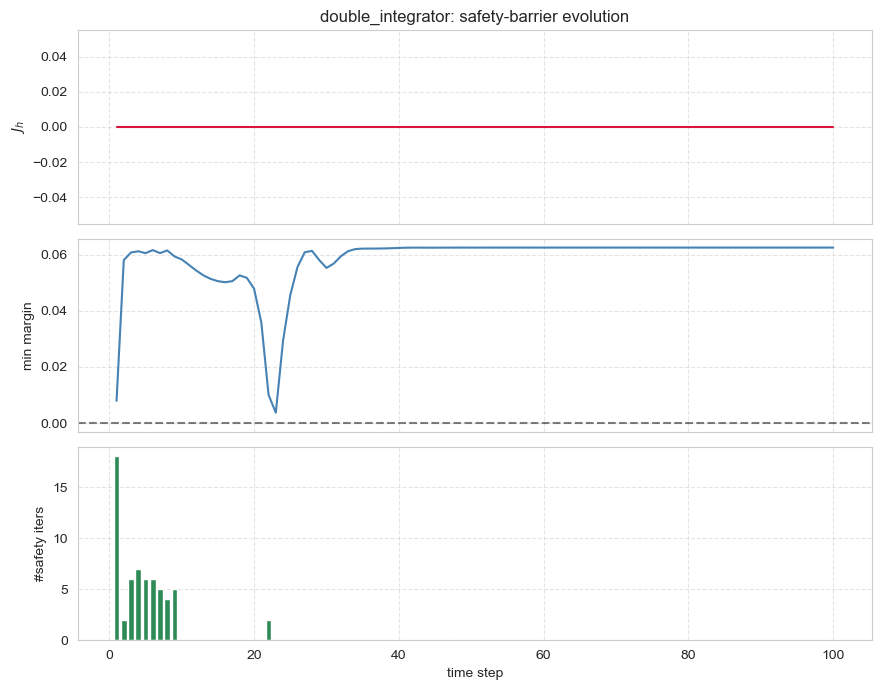

In [14]:
from sdpc.plotting import plot_barrier_evolution
import matplotlib.pyplot as plt

plot_barrier_evolution(res['logs'], title=f'{SYSTEM}: safety-barrier evolution')
plt.show()

## 10. Trajectory comparison: frozen, unconstrained, barrier, and PSF

Compare the executed trajectories.


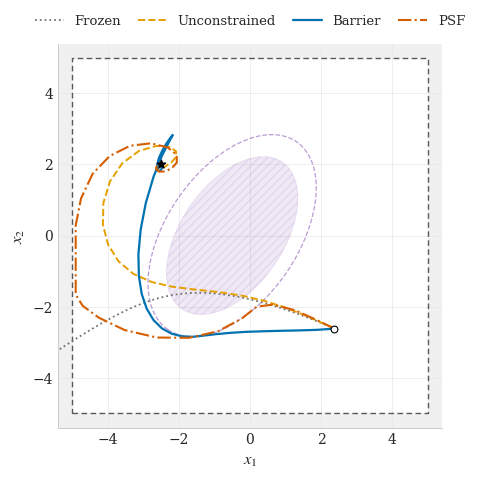

In [15]:
from sdpc.plotting import plot_trajectories_with_obstacles
import matplotlib.pyplot as plt

box_bounds = (float(cfg.get('safe_xmin', system.xmin)),
              float(cfg.get('safe_xmax', system.xmax)))
output_stem = RESULTS / 'figures' / 'double_integrator_safe_adaptation'

fig, ax = plot_trajectories_with_obstacles(
    [
        {'traj': res_frozen['x_traj'], 'label': 'Frozen', 'color': '0.45',
         'linestyle': ':', 'linewidth': 1.3, 'show_start': False},
        {'traj': res_unsafe['x_traj'], 'label': 'Unconstrained', 'color': '#E69F00',
         'linestyle': '--', 'linewidth': 1.4, 'show_start': False},
        {'traj': res['x_traj'], 'label': 'Barrier', 'color': '#0072B2',
         'linestyle': '-', 'linewidth': 1.6, 'show_start': False},
        {'traj': res_psf['x_traj'], 'label': 'PSF', 'color': '#D55E00',
         'linestyle': '-.', 'linewidth': 1.5, 'show_start': False},
    ],
    [cfg['ellipse']], r=data['r'],
    obstacle_band=float(cfg.get('bands', {}).get('obstacle', 0.0)),
    state_bounds=box_bounds, constraint_pad=0.4,
    publication=True, show_initial=True, reference_marker_size=38,
    title='', output_stem=str(output_stem),
)
plt.show()

## 11. Tracking, safety, smoothness, and computation metrics

Report obstacle encounter, sustained reference stabilization, safety, and runtime.


In [16]:
import numpy as np
import pandas as pd
from sdpc.eval import compute_metrics

method_runs = {
    'frozen': res_frozen,
    'unconstrained': res_unsafe,
    'safe_barrier': res,
    'psf': res_psf,
}

metric_cfg = cfg.get('metrics', {})
reach_tolerance = float(metric_cfg.get('reach_tolerance', 0.05))
reach_hold_steps = int(metric_cfg.get('reach_hold_steps', 5))
obstacle_constraints = [
    con for con in spec.state_constraints
    if con.meta.get('kind') == 'rotated_ellipse'
]

def first_obstacle_band_step(x_traj):
    if not obstacle_constraints:
        return np.nan
    active = torch.stack([
        con.margin(x_traj) <= con.delta + con.band
        for con in obstacle_constraints
    ]).any(dim=0).any(dim=0)
    indices = torch.nonzero(active, as_tuple=False).flatten()
    return int(indices[0].item()) if indices.numel() else np.nan

metric_rows = []
margin_rows = []
for method, run in method_runs.items():
    metrics = compute_metrics(
        run['x_traj'], run['u_traj'], data['r'],
        spec=spec, logs=run.get('logs'),
        reach_tolerance=reach_tolerance, reach_hold_steps=reach_hold_steps,
    )
    metric_rows.append({
        'method': method,
        'first_obstacle_band_step': first_obstacle_band_step(run['x_traj']),
        'reached_final_ref': metrics['reached_reference'],
        'steps_to_stabilize': metrics['steps_to_reach'],
        'stabilization_step': metrics['final_reference_stabilization_step'],
        'tracking_mse': metrics['tracking_mse'],
        'state_violations': metrics['num_state_violations'],
        'du_violations': metrics.get('num_control_rate_violations', 0),
        'min_state_margin': metrics['min_state_margin'],
        'min_du_margin': metrics.get('min_control_rate_margin', np.nan),
        'smooth_rms_du': metrics['control_smoothness_rms'],
        'mean_du_l2': metrics['mean_du_l2'],
        'max_du_l2': metrics['max_du_l2'],
        'online_total_s': metrics.get('runtime_total_s', np.nan),
        'online_ms_per_step': 1e3 * metrics.get('runtime_per_step_s', np.nan),
        'filter_ms_per_step': 1e3 * metrics.get('filter_runtime_per_step_s', np.nan),
        'solver_setup_s': run.get('setup_time_s', np.nan),
    })
    margin_rows.append({'method': method, **spec.min_margins(run['x_traj'])})

metrics_df = pd.DataFrame(metric_rows).set_index('method')
margins_df = pd.DataFrame(margin_rows).set_index('method')
display(metrics_df.round(5))
print('Constraint-wise minimum margins (negative means violated):')
display(margins_df.round(5))


,first_obstacle_band_step,reached_final_ref,steps_to_stabilize,stabilization_step,tracking_mse,state_violations,du_violations,min_state_margin,min_du_margin,smooth_rms_du,mean_du_l2,max_du_l2,online_total_s,online_ms_per_step,filter_ms_per_step,solver_setup_s
method,,,,,,,,,,,,,,,,
frozen,8.0,0.0,NaN,NaN,61.61953,94,0,-7.60496,0.06232,0.00668,0.00642,0.01358,NaN,NaN,NaN,NaN
unconstrained,5.0,1.0,32.0,32.0,2.79098,4,0,-2.90928,0.01050,0.06983,0.03368,0.22803,0.05892,0.58919,NaN,NaN
safe_barrier,NaN,1.0,40.0,40.0,4.51919,0,0,1.86384,0.00372,0.06207,0.03151,0.24244,0.39736,3.97356,NaN,0.00121
psf,4.0,1.0,33.0,33.0,3.90674,0,0,0.10000,0.00099,0.10940,0.05664,0.24801,0.70532,7.05323,4.364,0.01746


Constraint-wise minimum margins (negative means violated):


,obstacle,x0_min,x0_max,x1_min,x1_max
method,,,,,
frozen,-2.92936,-7.60496,2.62153,-3.84215,6.61029
unconstrained,-2.90928,0.86495,2.62153,2.38390,2.47861
safe_barrier,4.03123,1.86384,2.62153,2.15225,2.17032
psf,3.99995,0.10000,2.62153,2.12466,2.40391


In [17]:
from IPython.display import Video, display
from sdpc.plotting import animate_trajectories_with_ellipse

e = cfg["ellipse"]
video_path = RESULTS / "figures" / "safe_adaptation_barrier_vs_psf.mp4"

animate_trajectories_with_ellipse(
    [
        {
            "traj": res_frozen["x_traj"],
            "label": "Frozen",
            "color": "0.45",
            "linestyle": ":",
            "linewidth": 1.3,
            "show_start": False,
        },
        {
            "traj": res_unsafe["x_traj"],
            "label": "Unconstrained",
            "color": "#E69F00",
            "linestyle": "--",
            "linewidth": 1.4,
            "show_start": False,
        },
        {
            "traj": res["x_traj"],
            "label": "Barrier",
            "color": "#0072B2",
            "linestyle": "-",
            "linewidth": 1.6,
            "show_start": False,
        },
        {
            "traj": res_psf["x_traj"],
            "label": "PSF",
            "color": "#D55E00",
            "linestyle": "-.",
            "linewidth": 1.5,
            "show_start": False,
        },
    ],
    r=data["r"],
    p=e["p"],
    b=e["b"],
    c=e["c"],
    d=e["d"],
    theta=e.get("theta", 0.0),
    obstacle_band=float(cfg.get("bands", {}).get("obstacle", 0.0)),
    state_bounds=(float(cfg.get("safe_xmin", system.xmin)),
                  float(cfg.get("safe_xmax", system.xmax))),
    constraint_pad=0.4,
    publication=True,
    show_initial=True,
    reference_marker_size=38,
    title="",
    output_path=str(video_path),
    fps=20,
    dpi=150,
)

display(Video(str(video_path), embed=False, html_attributes="controls loop"))

## 12. Compare the squared-hinge and relaxed-log barriers

Compare the barrier penalty shapes.


In [18]:
# other_kind = 'relaxed_log' if scfg.barrier_kind == 'squared_hinge' else 'squared_hinge'
# scfg_other = SafeAdaptationConfig(**{**cfg.get('safe', {}), 'barrier_kind': other_kind})
# res_other = run_safe_adaptation(
#     copy.deepcopy(policy), plant, data, spec, scfg_other,
#     umin=system.umin, umax=system.umax,
# )
#
# m1 = spec.min_margins(res['x_traj'])
# m2 = spec.min_margins(res_other['x_traj'])
# print(f"{'constraint':>14} {scfg.barrier_kind:>16} {other_kind:>16}")
# for name in m1:
#     print(f'{name:>14} {m1[name]:>16.4f} {m2[name]:>16.4f}')